
# PneumoFusionNet — MIMIC-CXR Image Baseline  
## Binary Pneumonia Detection using ResNet50 + GCSA Attention + Depthwise Separable Convolution

### Project Overview
This notebook adapts PneumoFusionNet for the MIMIC-CXR JPG dataset (P10 subset).  
Phase 1 focuses on image-only binary classification.

The model combines:

- ResNet50 backbone (pretrained, 1-channel grayscale)
- Global Context Spatial Attention (GCSA)
- Depthwise Separable Convolution (DSC)

---

## Dataset

Dataset Used:
- MIMIC-CXR JPG (P10 folder — 595 images)

Classes:
- NORMAL   → No Finding = 1.0 in CheXpert
- PNEUMONIA → Pneumonia = 1.0 in CheXpert

Split: **80% Train / 20% Test (stratified)**

---

## Notebook Structure

1. Environment Setup  
2. Dataset Loading  
3. 80/20 Train/Test Split  
4. Transforms & DataLoaders  
5. Model Architecture  
6. Training  
7. Evaluation & Metrics  
8. Save Features for Phase 2  

---

## Author
IIT Guwahati  
B.Sc. in Data Science & Artificial Intelligence, IIT Guwahati  
📧 Email: ay346185@gmail.com

In [2]:
import os, random, copy, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score, auc
)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda': print('GPU:', torch.cuda.get_device_name(0))

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\2026\PneumoFusionNet\mimic\venv_PneumoFusionNet\lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [3]:
BASE_DIR   = r'C:\2026\project\mimic'
CSV_PATH   = r'C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\dataset_139\mimic_dataset.csv'
SAVE_DIR   = os.path.join(BASE_DIR, 'mimic_pilot', 'outputs')
MODEL_PATH = os.path.join(SAVE_DIR, 'best_pneumofusion_mimic.pth')
IMG_SIZE=224; BATCH_SIZE=8; NUM_EPOCHS=30; LR=1e-4; WEIGHT_DECAY=1e-4; NUM_CLASSES=2
CLASSES=['NORMAL','PNEUMONIA']; MEAN=[0.485]; STD=[0.229]
os.makedirs(SAVE_DIR, exist_ok=True)
print('CSV path:', CSV_PATH)
print('Exists  :', os.path.exists(CSV_PATH))

CSV path: C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\dataset_139\mimic_dataset.csv
Exists  : True


## Dataset Loading

In [4]:
df = pd.read_csv(CSV_PATH)
df['image_path'] = df['image_path'].apply(lambda x: x.replace(r'C:\2026\project\mimic\MIMIC_CXR_JPG_P1\p10', r'C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\mimic-cxr-jpg\2.1.0\files\p10'))
df_pneu = df[df['label_name'] == 'Pneumonia']
df_norm = df[df['label_name'] == 'Normal'].sample(n=len(df_pneu), random_state=42)
df = pd.concat([df_pneu, df_norm]).sample(frac=1, random_state=42).reset_index(drop=True)
print('Shape:', df.shape)
print(df['label_name'].value_counts())
df.head(10)

Shape: (42, 5)
Normal       21
Pneumonia    21
Name: label_name, dtype: int64


,subject_id,study_id,image_path,label,label_name
0,10001884,57839849,C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\...,0,Normal
1,10007928,59796203,C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\...,1,Pneumonia
2,10003019,58505074,C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\...,1,Pneumonia
3,10012569,56578283,C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\...,0,Normal
4,10002428,55758034,C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\...,1,Pneumonia
5,10011126,56036651,C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\...,0,Normal
6,10012292,53627836,C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\...,1,Pneumonia
7,10010231,57916297,C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\...,0,Normal
8,10007326,59442660,C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\...,0,Normal
9,10002428,59015983,C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\...,1,Pneumonia


## Visualise Sample Images

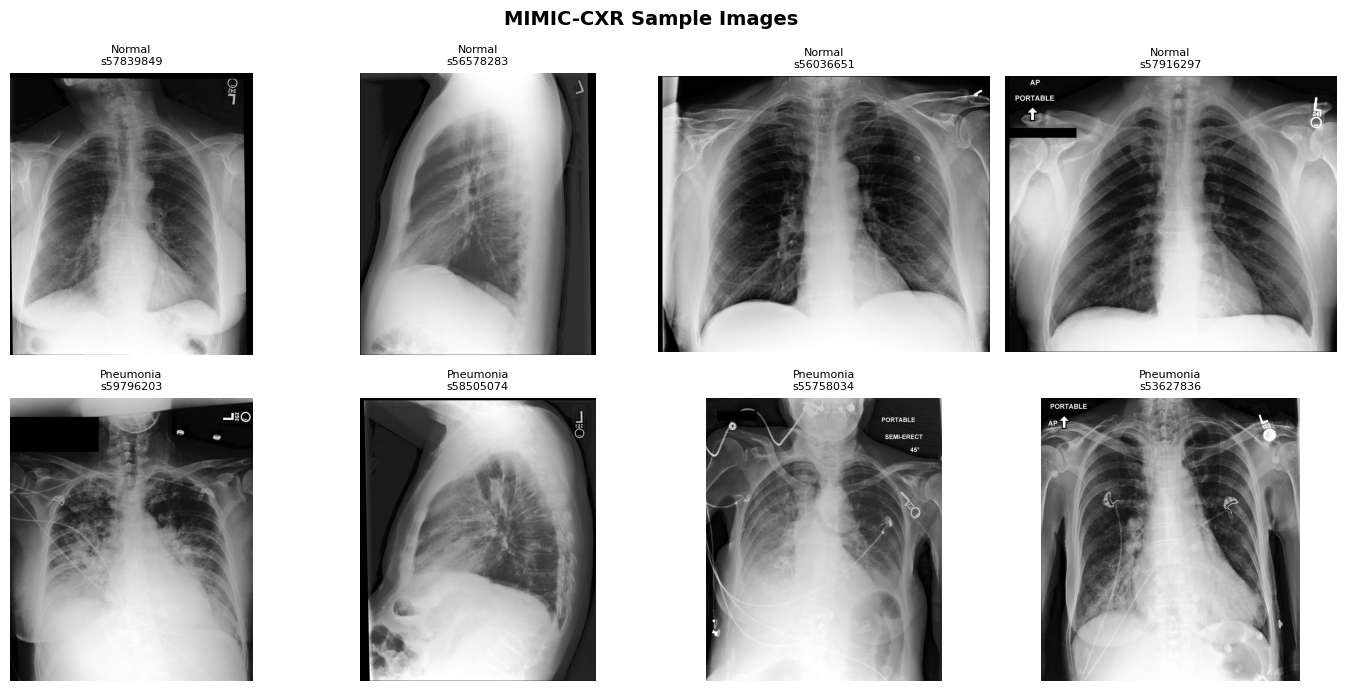

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('MIMIC-CXR Sample Images', fontsize=14, fontweight='bold')
for row, lname in enumerate(['Normal', 'Pneumonia']):
    subset = df[df.label_name == lname].head(4)
    for col, (_, rec) in enumerate(subset.iterrows()):
        ax = axes[row][col]
        img = Image.open(rec.image_path).convert('L')
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{lname}\ns{rec.study_id}', fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_images.png'), dpi=120)
plt.show()

## Train / Test Split — 80 / 20 (Stratified)

In [6]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df['label']
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print('Train:', len(train_df), '| Pneumonia:', train_df.label.sum(), '| Normal:', (train_df.label==0).sum())
print('Test :', len(test_df),  '| Pneumonia:', test_df.label.sum(),  '| Normal:', (test_df.label==0).sum())

NameError: name 'train_test_split' is not defined

## Transforms — Grayscale (1 Channel)

In [7]:
tfms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256, 256)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.25, contrast=0.25),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
}
print('Grayscale transforms ready.')

Grayscale transforms ready.


## Dataset Class & DataLoaders

In [8]:
class MIMICDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.image_path)
        if self.transform: img = self.transform(img)
        return img, int(row.label)

# WeightedRandomSampler to handle class imbalance
train_labels  = train_df['label'].values
class_counts  = np.bincount(train_labels)
sample_weights = [1.0 / class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

dataloaders = {
    'train': DataLoader(MIMICDataset(train_df, tfms['train']), batch_size=BATCH_SIZE,
                        sampler=sampler),
    'test':  DataLoader(MIMICDataset(test_df,  tfms['test']),  batch_size=BATCH_SIZE,
                        shuffle=False),
}
dataset_sizes = {'train': len(train_df), 'test': len(test_df)}
print('Dataset sizes:', dataset_sizes)
# Verify 1-channel input
sample_batch, _ = next(iter(dataloaders['train']))
print('Batch shape (B,C,H,W):', sample_batch.shape)

Dataset sizes: {'train': 111, 'test': 28}
Batch shape (B,C,H,W): torch.Size([8, 1, 224, 224])


## Model Architecture — PneumoFusionNet

Input X-ray  
→ Preprocessing  
→ ResNet50 Feature Extraction  
→ Depthwise Separable Convolution (DSC)  
→ GCSA Attention  
→ Classification Head  
→ Pneumonia Prediction

In [9]:
class GCSA(nn.Module):
    """Global Channel-Spatial Attention"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels)
        )
        self.sigmoid      = nn.Sigmoid()
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        B, C, H, W = x.shape
        avg    = self.avg_pool(x).view(B, C)
        mx     = self.max_pool(x).view(B, C)
        ch_att = self.sigmoid(self.mlp(avg) + self.mlp(mx)).view(B, C, 1, 1)
        x      = x * ch_att
        sp     = torch.cat([x.mean(1, keepdim=True), x.max(1, keepdim=True)[0]], dim=1)
        return x * self.sigmoid(self.conv_spatial(sp))


class DSC(nn.Module):
    """Depthwise Separable Convolution"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch,  3, padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return F.relu(self.bn(self.pw(self.dw(x))), inplace=True)


class PneumoFusionNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, freeze_until=6):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        # Adapt conv1: 3-channel → 1-channel (grayscale)
        resnet.conv1 = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            resnet.conv1.weight = nn.Parameter(
                resnet.conv1.weight.mean(dim=1, keepdim=True)
            )
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        for i, child in enumerate(self.backbone.children()):
            if i < freeze_until:
                for p in child.parameters(): p.requires_grad = False
        self.dsc  = DSC(2048, 1024)
        self.gcsa = GCSA(1024)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)        # [B, 2048, 7, 7]
        x = self.dsc(x)             # [B, 1024, 7, 7]
        x = self.gcsa(x)            # [B, 1024, 7, 7]
        x = self.pool(x).flatten(1) # [B, 1024]
        return self.classifier(x)    # [B, 2]

    def get_features(self, x):
        """1024-d embedding for Phase 2 multimodal fusion."""
        x = self.backbone(x)
        x = self.dsc(x)
        x = self.gcsa(x)
        return self.pool(x).flatten(1)

In [11]:
model = PneumoFusionNet().to(DEVICE)
# Sanity check
dummy = torch.randn(4, 1, 224, 224).to(DEVICE)
print('Output shape  :', model(dummy).shape)               # [4, 2]
print('Feature shape :', model.get_features(dummy).shape)  # [4, 1024]
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,} ({trainable/total*100:.1f}%)')

Output shape  : torch.Size([4, 2])
Feature shape : torch.Size([4, 1024])
Total params    : 26,277,477
Trainable params: 24,838,821 (94.5%)


## Loss, Optimiser & Scheduler

In [12]:
# Inverse-frequency class weights
n0 = (train_df.label == 0).sum(); n1 = (train_df.label == 1).sum(); N = len(train_df)
w0 = N / (2 * n0); w1 = N / (2 * n1)
class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
print(f'Normal weight    : {w0:.3f}')
print(f'Pneumonia weight : {w1:.3f}')

Normal weight    : 0.590
Pneumonia weight : 3.265


## Training

In [13]:
train_losses = []
best_loss    = float('inf')

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0; correct = 0; n = 0
    for imgs, labels in dataloaders['train']:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (outputs.argmax(1) == labels).sum().item()
        n          += len(labels)
    scheduler.step()
    epoch_loss = total_loss / n; epoch_acc = correct / n
    train_losses.append(epoch_loss)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), MODEL_PATH)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.3f}')

print(f'\nBest Train Loss : {best_loss:.4f}')
print(f'Model saved to  : {MODEL_PATH}')

Epoch [5/30]  Loss: 0.3145  Acc: 0.739
Epoch [10/30]  Loss: 0.2814  Acc: 0.865
Epoch [15/30]  Loss: 0.0733  Acc: 0.955
Epoch [20/30]  Loss: 0.1291  Acc: 0.910
Epoch [25/30]  Loss: 0.0703  Acc: 0.955
Epoch [30/30]  Loss: 0.3813  Acc: 0.883

Best Train Loss : 0.0382
Model saved to  : C:\2026\project\mimic\mimic_pilot\outputs\best_pneumofusion_mimic.pth


## Training Loss Curve

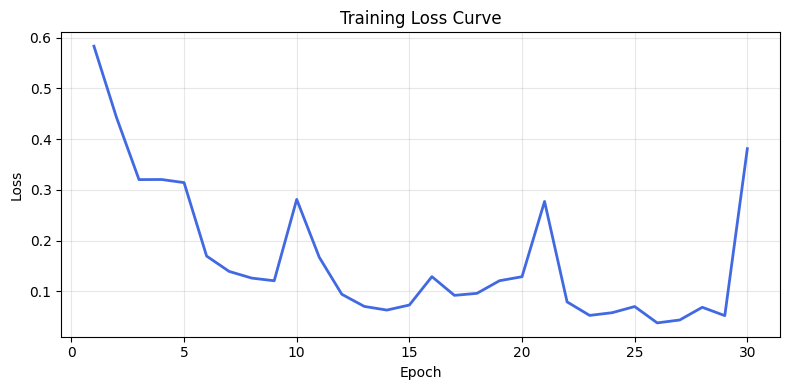

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, color='royalblue', lw=2)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'train_loss.png'), dpi=120)
plt.show()

## Evaluation on Test Set

In [15]:
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
all_preds = []; all_labels = []; all_probs = []
with torch.no_grad():
    for imgs, labels in dataloaders['test']:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        probs   = F.softmax(outputs, dim=1)[:, 1]
        all_preds  += outputs.argmax(1).cpu().tolist()
        all_labels += labels.cpu().tolist()
        all_probs  += probs.cpu().tolist()
print(classification_report(all_labels, all_preds, target_names=CLASSES))

              precision    recall  f1-score   support

      NORMAL       0.92      0.92      0.92        24
   PNEUMONIA       0.50      0.50      0.50         4

    accuracy                           0.86        28
   macro avg       0.71      0.71      0.71        28
weighted avg       0.86      0.86      0.86        28



## Confusion Matrix

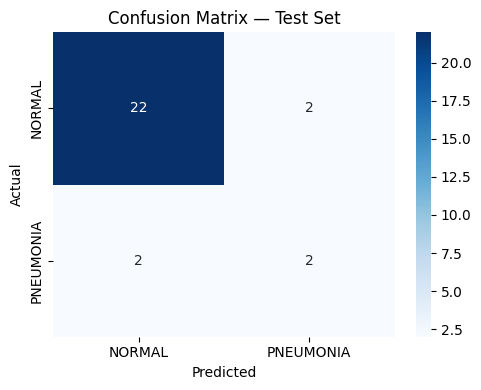

In [16]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()

## ROC Curve

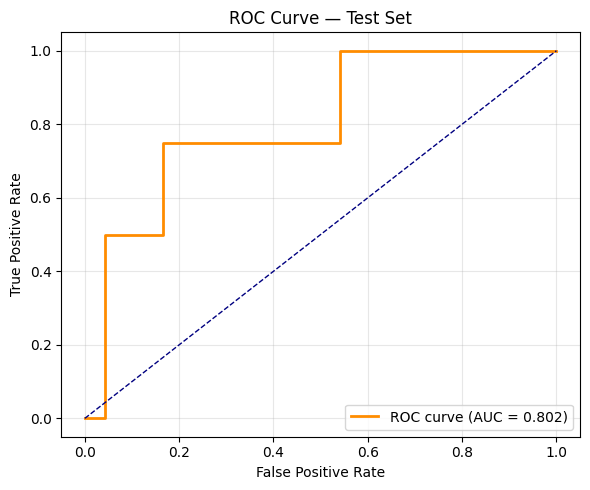

AUC: 0.8021


In [17]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'roc_curve.png'), dpi=120)
plt.show()
print(f'AUC: {roc_auc:.4f}')

## Final Metrics Summary

In [18]:
acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, zero_division=0)
print('=' * 40)
print('  TEST SET RESULTS')
print('=' * 40)
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  AUC       : {roc_auc:.4f}')
print('=' * 40)
print()
print('Outputs saved to:', SAVE_DIR)
print('  - best_pneumofusion_mimic.pth')
print('  - train_loss.png')
print('  - confusion_matrix.png')
print('  - roc_curve.png')

  TEST SET RESULTS
  Accuracy  : 0.8571
  F1 Score  : 0.5000
  AUC       : 0.8021

Outputs saved to: C:\2026\project\mimic\mimic_pilot\outputs
  - best_pneumofusion_mimic.pth
  - train_loss.png
  - confusion_matrix.png
  - roc_curve.png


## Save Image Features for Phase 2 — Multimodal Fusion

In [21]:
all_loader = DataLoader(MIMICDataset(df, tfms['test']), batch_size=BATCH_SIZE, shuffle=False)
feats, labs = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in all_loader:
        feats.append(model.get_features(imgs.to(DEVICE)).cpu())
        labs += labels.tolist()
img_features = torch.cat(feats)  # [139, 1024]
feat_path    = os.path.join(SAVE_DIR, 'image_features.pt')
torch.save({'features': img_features, 'labels': labs}, feat_path)
print(f'Image features shape : {img_features.shape}')
print(f'Saved to             : {feat_path}')
print()
print('Phase 1 COMPLETE. Next: Add radiology text → multimodal fusion (Phase 2).')

Image features shape : torch.Size([139, 1024])
Saved to             : C:\2026\project\mimic\mimic_pilot\outputs\image_features.pt

Phase 1 COMPLETE. Next: Add radiology text → multimodal fusion (Phase 2).
